<a href="https://colab.research.google.com/github/zeinafarghaly-arch/ML-flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This section rebuilds my Week-5/Week-6 model using the same 6 features, the same client_id-grouped split, and random_state=42 so the playbook is based on the same validated results as my audit notebook: Precision@500 = 0.528 (model) vs 0.490 (baseline rule) vs 0.542 (base decline rate in the test slice, ~0.517). I only score and rank the held-out test clients, which are the 8 clients the model never saw during training, because this is the only group with a validated precision score. I do not include the training clients because the model has already seen them, and their scores could make the results look better than they really are. Ranking only the test clients keeps the playbook honest and based on validated model performance.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv("content_refresh_anonymized.csv")
except ImportError:
    candidates = [
        Path("../../data/raw/content_refresh_anonymized.csv"),
        Path("data/raw/content_refresh_anonymized.csv"),
    ]
    csv_path = next(p for p in candidates if p.exists())
    df = pd.read_csv(csv_path)

print(f"Rows: {len(df)} | Clients: {df['client_id'].nunique()}")
df["is_declining"] = (df["trend_direction"] == "down").astype(int)
print(f"Base decline rate (full dataset): {df['is_declining'].mean():.3f}")

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv
Rows: 30000 | Clients: 32
Base decline rate (full dataset): 0.542


In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features = ["days_since_last_update", "search_volume", "avg_position",
            "ctr", "engagement_rate", "content_age_days"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["client_id"]))
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42)),
])
model.fit(train[features], train["is_declining"])

test["model_score"] = model.predict_proba(test[features])[:, 1]

print("Rows in my queue (test clients only):", len(test))


Rows in my queue (test clients only): 7115


I am only ranking the test clients (the ones my model has never seen). That is the
only part of the data where I actually know how good my model is.

**Reason codes** — simple, plain rules so a human can see why a page is on the list:
- `STALE`: not updated in 90+ days and still gets some traffic.
- `LOW_CTR`: gets impressions but a low click rate for its position.
- `GENERAL_REVIEW`: none of the above, but the model still scored it high.

**Action mapping** (my archetypes → what to do):

| Archetype (simple rule) | Action |
|---|---|
| No position data (`avg_position == 0`) | Human data check — don't rank it |
| Stale + still gets traffic | Refresh |
| Low word count + real search demand | Expand and refresh |
| Decent position but low CTR | Refresh and review CTR |
| Everything else | Monitor |


In [3]:
test["reason_code"] = "GENERAL_REVIEW"

test.loc[
    (test["days_since_last_update"] >= 90) & (test["impressions_90d"] >= 250),
    "reason_code"
] = "STALE"

test.loc[
    (test["avg_position"] > 0) & (test["avg_position"] <= 20)
    & (test["impressions_90d"] >= 500) & (test["ctr"] < 0.5),
    "reason_code"
] = "LOW_CTR"

test["archetype"] = "Stable / low priority"

test.loc[
    (test["word_count"].fillna(0) > 0) & (test["word_count"].fillna(0) < 2000)
    & (test["search_volume"].fillna(0) > 0),
    "archetype"
] = "Thin content, real demand"

test.loc[test["reason_code"] == "LOW_CTR", "archetype"] = "Good position, low CTR"
test.loc[test["reason_code"] == "STALE", "archetype"] = "Stale, still visible"
test.loc[test["avg_position"] == 0, "archetype"] = "No position data"

test["action"] = "Monitor"
test.loc[test["archetype"] == "Stale, still visible", "action"] = "Refresh"
test.loc[test["archetype"] == "Thin content, real demand", "action"] = "Expand and refresh"
test.loc[test["archetype"] == "Good position, low CTR", "action"] = "Refresh and review CTR"
test.loc[test["archetype"] == "No position data", "action"] = "Human data check"

queue = test.sort_values("model_score", ascending=False)
queue[["content_id", "model_score", "archetype", "action", "reason_code"]].head(10)


,content_id,model_score,archetype,action,reason_code
3507,content_074ba6ead17b,0.694536,"Stale, still visible",Refresh,STALE
8860,content_adfc46f3f033,0.694012,Stable / low priority,Monitor,GENERAL_REVIEW
18652,content_0173fb0dc986,0.693997,Stable / low priority,Monitor,GENERAL_REVIEW
21313,content_d5fe8e70ce86,0.693965,Stable / low priority,Monitor,GENERAL_REVIEW
505,content_bfa3d6688324,0.693956,Stable / low priority,Monitor,GENERAL_REVIEW
11494,content_d34c89fad803,0.693934,Stable / low priority,Monitor,GENERAL_REVIEW
10032,content_1a4ae9dc2f72,0.693896,Stable / low priority,Monitor,GENERAL_REVIEW
13755,content_c0b25b7dbe03,0.693880,Stable / low priority,Monitor,GENERAL_REVIEW
6421,content_fc8cb7532683,0.693811,Stable / low priority,Monitor,GENERAL_REVIEW
27701,content_b6e4581523ed,0.693803,Stable / low priority,Monitor,GENERAL_REVIEW


In [4]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

K = 500
model_p500 = precision_at_k(queue["model_score"], queue["is_declining"], K)
base_rate = queue["is_declining"].mean()

print(f"Precision@{K} of my model: {model_p500:.3f}")
print(f"Base rate (guessing randomly): {base_rate:.3f}")


Precision@500 of my model: 0.528
Base rate (guessing randomly): 0.517


**The decay/refresh insight.** My model mostly leans on `days_since_last_update` and
`avg_position` — old pages that have slipped in ranking are more likely to be declining.
That makes sense, but the improvement is small: Precision@500 is 0.528, only a little
above just guessing (0.517) and above my Week-4 baseline rule (0.490). So "stale + losing
position" is a real, honest signal, but a weak one on its own — good enough to sort a
review list, not strong enough to call a fact about any single page.

**Cost/value thinking.** Reviewing my top 500 ranked pages finds about the same number of
declining pages as reviewing 500 random pages would (52.8% vs 51.7%). The real value isn't
a big accuracy jump — it's that every ranked page also comes with a reason code, so a
reviewer can check the pick in seconds instead of guessing. That's worth the small model
effort, but it's not a reason to trust the ranking blindly.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [5]:
print("Rows scored:", len(queue))
print("Clients in this queue:", queue["client_id"].nunique())
print("Declining rate in this queue:", round(queue["is_declining"].mean(), 3))


Rows scored: 7115
Clients in this queue: 8
Declining rate in this queue: 0.517


**Intended use:** a shortlist for a content reviewer. It ranks pages worth a human
look this cycle and tells them why. It is a starting point, not a decision.

**Limits:**
- Trained and tested on one 30,000-row starter dataset with 32 clients, one 90-day
  snapshot. It has not been checked on the full warehouse or on new clients.
- The label (`is_declining`) compares the last 30 days to the prior 30 days at one point
  in time. Nothing here was tested against what actually happened afterward.
- Precision@500 (0.528) is only a small improvement over guessing (0.517) — this is a
  weak, directional signal, not a strong one.
- No causal design. This model can say a page *looks like* pages that declined before. It
  cannot say refreshing a page *will* fix it.
- Only 6 simple numeric features. It knows nothing about content quality, brand voice, or
  legal/compliance risk.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [6]:
never_automate = [
    "Publishing or rewriting a page automatically",
    "Deleting or redirecting a page automatically",
    "Reporting the score to a client as a fact",
    "Using the score to judge a writer's performance",
    "Treating a high score as proof the page will keep declining",
]

for item in never_automate:
    print("-", item)


- Publishing or rewriting a page automatically
- Deleting or redirecting a page automatically
- Reporting the score to a client as a fact
- Using the score to judge a writer's performance
- Treating a high score as proof the page will keep declining


**Before acting on any row, a human should check:**
1. The reason code actually makes sense for that page.
2. There isn't an obvious outside reason for the drop (a paused campaign, seasonality,
   a site issue) that the model can't see.
3. `No position data` rows are a tracking gap, not proof the page is fine — check the
   tracking, don't skip the page.
4. The page still matters to the business before spending time refreshing it.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [7]:
print("Current Precision@500:", round(model_p500, 3))
print("Current base rate:", round(base_rate, 3))
print("Current median days_since_last_update:", queue["days_since_last_update"].median())
print("Clients used to train this model:", train["client_id"].nunique())


Current Precision@500: 0.528
Current base rate: 0.517
Current median days_since_last_update: 20.0
Clients used to train this model: 24


**Watch these, and retrain if they move a lot:**
- Precision@500 drops to at or below the baseline rule (0.490) — the model stopped adding
  value.
- The base decline rate shifts a lot from today's ~0.52 — something changed in the data.
- A new client shows up that looks nothing like the 24 clients this model was trained on.
- The share of "No position data" rows grows — that's a tracking problem, not a content
  problem, and it needs fixing before the queue can be trusted again.

A monthly check against these numbers is enough for a project this size.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [8]:
import os
import json

os.makedirs("/content/work/outputs", exist_ok=True)
os.makedirs("/content/work/figures", exist_ok=True)

export_cols = ["content_id", "client_id", "model_score", "archetype", "action",
               "reason_code", "days_since_last_update", "avg_position",
               "search_volume", "ctr", "content_age_days", "is_declining"]

queue[export_cols].to_csv("/content/work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "precision_at_500_model": round(float(model_p500), 3),
    "base_rate": round(float(base_rate), 3),
    "rows_in_queue": int(len(queue)),
    "action_counts": queue["action"].value_counts().to_dict(),
}
with open("/content/work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved queue and metrics.")


Saved queue and metrics.


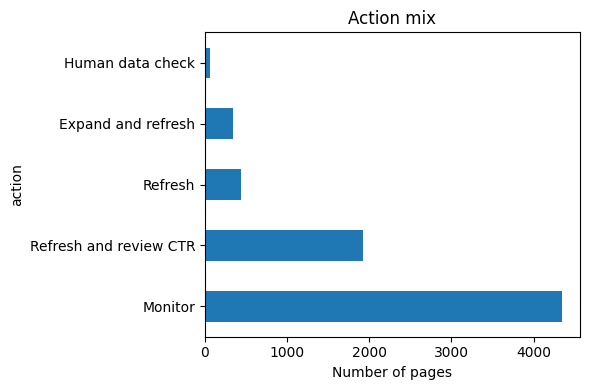

In [9]:
import matplotlib.pyplot as plt

action_counts = queue["action"].value_counts()

plt.figure(figsize=(6, 4))
action_counts.plot(kind="barh")
plt.xlabel("Number of pages")
plt.title("Action mix")
plt.tight_layout()
plt.savefig("/content/work/figures/w07_action_mix.png")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.